In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-foundations.6j_z9po4/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-foundations.6j_z9po4/venv", "python": "3.12.14", "torch_cuda_build": null}


# More candidates can expose scorer mistakes

Day 26 · Chapter 15 · CPU worked notebook

Read Chapter15 sections15.1–15.4.


### Prediction

Predict: must selected accuracy rise when at least one correct candidate becomes more likely? What if the scorer favors a common wrong answer?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [2]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "dongxi_llms").is_dir())
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (8, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
# CPU only. Local original fixtures; no checkpoint/network/server needed.


### Prediction

Controlled change: edit the finite simulator's score ordering in a copied experiment, predict each curve and record that new source identity. Evidence boundary: all candidate costs here are illustrative; scores are synthetic; independent draws do not reproduce correlated LLM errors.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


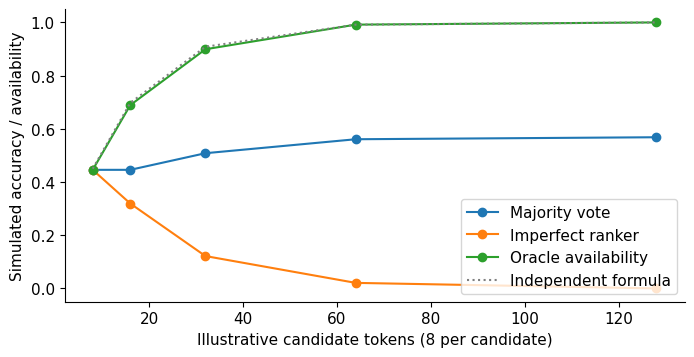

categorical Monte Carlo simulation 1200 trials; categorical draws, not LLM output


In [3]:
from dongxi_llms.distillation_lab import inference_comparison, majority_vote
result = inference_comparison()
rows = result["rows"]
fig, ax = plt.subplots()
for key, label in (("majority_accuracy", "Majority vote"),
                   ("proxy_best_n_accuracy", "Imperfect ranker"),
                   ("oracle_any_correct", "Oracle availability")):
    ax.plot([r["candidate_token_budget"] for r in rows], [r[key] for r in rows],
            marker="o", label=label)
ax.plot([r["candidate_token_budget"] for r in rows],
        [r["oracle_iid_formula"] for r in rows], linestyle=":", color="gray", label="Independent formula")
ax.set(xlabel="Illustrative candidate tokens (8 per candidate)", ylabel="Simulated accuracy / availability")
ax.legend()
plt.show()
print(result["mode"], result["trials"], "trials; categorical draws, not LLM output")

### Reference explanation

Reference explanation: oracle availability asks whether a correct answer exists; a deployed ranker must identify it. The ranker in this simulator increasingly selects its favored wrong class.

**Exercise modification reference.** 

```python
generator = torch.Generator().manual_seed(2628)
distribution = torch.tensor([.45, .40, .15], dtype=torch.float64)
draws = torch.multinomial(distribution, 1200*16, replacement=True, generator=generator).reshape(1200,16)
changed_scores = torch.tensor([.9, .7, .2], dtype=torch.float64)
for n in (1,2,4,8,16):
    pool = draws[:, :n]
    selected = pool.gather(1, changed_scores[pool].argmax(1, keepdim=True)).squeeze(1)
    available = (pool == 0).any(1)
    torch.testing.assert_close(selected == 0, available)
    majority = sum(majority_vote(row.tolist()) == 0 for row in pool)/1200
    print(n, majority, float((selected == 0).double().mean()), float(available.double().mean()))
```

Correct action now has the highest score, so selected correctness equals availability on each same-seed pool. Majority is unaffected by score order. This is a new finite simulator variant with illustrative costs. This concrete CPU variant has not been executed by the unchanged reference cell; it supplies an exercise reference rather than a new measured result.


Saved reference preview from the bounded CPU reference execution. It is a fixed result; run the cells to regenerate figures after changing controls. Compare this fixed preview with your prediction and the current plot.

![Saved reference 1: selection and sampling](../figures/chapter-15/day-26-02_selection_and_sampling-01.png)

### Prediction

Exercise: test majority ties and estimate rejection cost if acceptance is0.1 rather than0.5.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [4]:
assert majority_vote([3, 4, 4, 3]) == 3  # earliest candidate among tied modal answers
candidate_cost = 32
for acceptance in (.5, .1):
    print("Acceptance:", acceptance, "projected tokens per accepted example:",
          candidate_cost/acceptance)
print("Retry limits and prompt difficulty change the accepted data mixture.")

Acceptance: 0.5 projected tokens per accepted example: 64.0
Acceptance: 0.1 projected tokens per accepted example: 320.0
Retry limits and prompt difficulty change the accepted data mixture.


### Reference explanation

The tied majority uses the earliest candidate among tied modal answers. At an illustrative 32 tokens per attempt, acceptance .5 costs an expected 64 tokens per accepted example and acceptance .1 costs 320. These are geometric cost projections, not measured LLM retry costs.
